# Image Embeddings — PCA + K-Means Clustering with Voyage AI

Embeds **30 Wikimedia Commons images** (6 categories × 5 images) using
`voyage-multimodal-3`, then applies PCA and K-Means to group similar images.

| Stage | What it does |
|---|---|
| **Image discovery** | Wikimedia Commons search API — finds real photos by keyword, no filename guessing |
| **Verification** | Visual grid shown **before** any tokens are spent |
| **Embedding** | Free-tier safe — batched in groups of 5 with rate-limit sleep + token counter |
| **PCA** | Scree plot · 2-D scatter · whitened space |
| **K-Means** | Elbow method · cluster assignment · purity analysis |
| **Retrieval** | Cluster-aware text → image search |

**Prerequisites**: Voyage AI API key (`VOYAGEAI_API_KEY` in `.env`).  
Free-tier (10 K tokens / min) is sufficient for this demo.


## 1. Setup

In [ ]:
# %pip install voyageai pillow requests python-dotenv scikit-learn matplotlib numpy


In [1]:
import os
import io
import time
import random
from collections import Counter
from typing import Optional, List, Tuple

import requests
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from dotenv import load_dotenv

import voyageai
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize

load_dotenv()

VOYAGEAI_API_KEY = os.getenv("VOYAGEAI_API_KEY")
assert VOYAGEAI_API_KEY, "Set VOYAGEAI_API_KEY in your .env file"

vo = voyageai.Client(api_key=VOYAGEAI_API_KEY)
print("✅  Voyage AI client ready")


✅  Voyage AI client ready


## 2. Corpus definition

Instead of guessing Wikimedia filenames (which silently fail and return the wrong image),
we use the **Commons full-text search API** (`generator=search`, namespace 6 = Files).
The API searches filenames *and* descriptions, then returns real JPEG/PNG photos.

Results are filtered to:
- **BITMAP** media type only (no SVG diagrams, maps, or icons)
- Minimum **300 × 200 px** original size (excludes tiny icons)
- Downloaded at **200 px** thumbnail width → keeps token usage low on the free tier


In [2]:
# Search terms are sent to the Wikimedia Commons full-text search in the File namespace.
# Use specific, descriptive terms to maximise photo relevance.
SEARCH_TERMS: dict = {
    "cat":      "domestic cat feline portrait",
    "dog":      "domestic dog canine portrait",
    "bird":     "wild bird colorful perched",
    "car":      "automobile car road exterior",
    "mountain": "mountain peak snow landscape",
    "flower":   "flower bloom colorful garden",
}

IMAGES_PER_CATEGORY = 5    # target images per category
THUMB_WIDTH         = 200  # thumbnail width in pixels (keeps token cost low)
MIN_ORIG_WIDTH      = 300  # minimum original image width (filters out icons)
MIN_ORIG_HEIGHT     = 200  # minimum original image height
CATEGORY_LIST       = list(SEARCH_TERMS.keys())


## 3. Discover and download images

In [3]:
WM_API      = "https://commons.wikimedia.org/w/api.php"
WM_FILEPATH = "https://commons.wikimedia.org/wiki/Special:FilePath"

# ── Session headers ───────────────────────────────────────────────────────────
# Special:FilePath goes through commons.wikimedia.org (not the upload CDN)
# and is far less likely to be geo-blocked.
SESSION = requests.Session()
SESSION.headers.update({
    "User-Agent":      "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                       "AppleWebKit/537.36 (KHTML, like Gecko) "
                       "Chrome/124.0.0.0 Safari/537.36",
    "Accept":          "image/avif,image/webp,image/apng,image/*,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.9",
    "Referer":         "https://commons.wikimedia.org/",
})

SEARCH_DELAY   = 2.5   # seconds between category searches
DOWNLOAD_DELAY = 0.5   # seconds between individual downloads


def search_commons_filenames(query: str, fetch_limit: int = 50) -> List[str]:
    """
    Search Wikimedia Commons (namespace 6 = File) for BITMAP photos.
    Returns a list of bare filenames (no "File:" prefix).
    Thumbnails are NOT requested here — we build our own download URLs below.
    """
    params = {
        "action":        "query",
        "generator":     "search",
        "gsrnamespace":  6,
        "gsrsearch":     query,
        "gsrlimit":      fetch_limit,
        "prop":          "imageinfo",
        "iiprop":        "mediatype|size",   # no url — we build it ourselves
        "format":        "json",
    }
    for attempt in range(4):
        try:
            resp = SESSION.get(WM_API, params=params, timeout=30)
            resp.raise_for_status()
            pages = resp.json().get("query", {}).get("pages", {})
            break
        except Exception as exc:
            wait = 3 * (attempt + 1)
            print(f"    Search attempt {attempt + 1} failed: {exc} — retrying in {wait}s")
            time.sleep(wait)
    else:
        print(f"    All search retries exhausted for: {query}")
        return []

    filenames: List[str] = []
    for page in pages.values():
        ii_list = page.get("imageinfo", [])
        if not ii_list:
            continue
        ii = ii_list[0]
        if ii.get("mediatype") != "BITMAP":
            continue
        if ii.get("width",  0) < MIN_ORIG_WIDTH:
            continue
        if ii.get("height", 0) < MIN_ORIG_HEIGHT:
            continue
        name = page.get("title", "").replace("File:", "").strip()
        if name:
            filenames.append(name)

    return filenames


def build_filepath_url(filename: str, width: int = THUMB_WIDTH) -> str:
    """
    Return a Special:FilePath URL that serves the image via commons.wikimedia.org
    rather than the upload CDN.  This bypasses geo-blocks on upload.wikimedia.org.
    """
    return f"{WM_FILEPATH}/{requests.utils.quote(filename)}?width={width}"


def download_image(filename: str) -> Optional[Image.Image]:
    """
    Download one image through Special:FilePath with up to 3 retries.
    Prints the HTTP status on failure so debugging is straightforward.
    """
    url = build_filepath_url(filename)
    for attempt in range(3):
        try:
            resp = SESSION.get(url, timeout=30, allow_redirects=True)
            if resp.status_code == 200:
                content_type = resp.headers.get("Content-Type", "")
                if "image" in content_type and len(resp.content) > 2_000:
                    try:
                        return Image.open(io.BytesIO(resp.content)).convert("RGB")
                    except Exception as img_err:
                        print(f"    ✗ PIL error on {filename[:50]}: {img_err}")
                        return None
                else:
                    print(f"    ✗ Bad content ({content_type}, {len(resp.content)} B): "
                          f"{filename[:50]}")
                    return None
            else:
                print(f"    ✗ HTTP {resp.status_code}: {filename[:50]}")
                if resp.status_code in (429, 503):
                    time.sleep(6 * (attempt + 1))
                else:
                    return None   # 403/404 will not improve on retry
        except Exception as exc:
            print(f"    ✗ Download error (attempt {attempt + 1}): {exc}")
            time.sleep(3 * (attempt + 1))
    return None


# ── Build flat corpus ─────────────────────────────────────────────────────────
images_flat:    List[Image.Image] = []
true_labels:    List[str]         = []
filenames_used: List[str]         = []

print("Searching Wikimedia Commons …\n")
for cat_idx, (cat, query) in enumerate(SEARCH_TERMS.items()):
    if cat_idx > 0:
        print(f"  ⏸  Waiting {SEARCH_DELAY}s before next search …")
        time.sleep(SEARCH_DELAY)

    print(f"  🔍 [{cat}]  Searching: \"{query}\"")
    filenames = search_commons_filenames(query)
    print(f"      Found {len(filenames)} candidates after filters")

    collected: List[Image.Image] = []
    for filename in filenames:
        if len(collected) >= IMAGES_PER_CATEGORY:
            break

        img = download_image(filename)
        if img is not None:
            collected.append(img)
            filenames_used.append(filename)
            print(f"  ✓ {cat:<12} {str(img.size):<14} {filename[:52]}")
        time.sleep(DOWNLOAD_DELAY)

    if len(collected) < IMAGES_PER_CATEGORY:
        print(f"  ⚠  {cat}: only {len(collected)}/{IMAGES_PER_CATEGORY} collected "
              "— try a broader search term in Section 2 if needed")

    images_flat.extend(collected)
    true_labels.extend([cat] * len(collected))
    print()

N              = len(images_flat)
true_label_idx = [CATEGORY_LIST.index(l) for l in true_labels]

assert N > 0, "No images downloaded — check your network connection"
print(f"✅  Corpus ready: {N} images across {len(CATEGORY_LIST)} categories")


Searching Wikimedia Commons …

  🔍 [cat]  Searching: "domestic cat feline portrait"
      Found 46 candidates after filters
  ✓ cat          (250, 333)     ADOPTED! Gooch (306793864).jpg
  ✓ cat          (250, 152)     Aladin 8200 (20801762121).jpg
  ✓ cat          (250, 333)     Black Shorthaired Tabby Cat.jpg
    ✗ HTTP 429: Cat - ^50 for 113 Pictures in 2013 ^^EXPLORED - Fl
  ✓ cat          (250, 187)     Cat - ^50 for 113 Pictures in 2013 ^^EXPLORED - Flic
    ✗ HTTP 429: Cat - opaque background (2720791942).jpg
  ✓ cat          (250, 394)     Cat - opaque background (2720791942).jpg

  ⏸  Waiting 2.5s before next search …
  🔍 [dog]  Searching: "domestic dog canine portrait"
      Found 2 candidates after filters
  ✓ dog          (250, 377)     Portrait of an English Bulldog. - Flickr - shixart19
    ✗ HTTP 429: The mascot pup after a bath 1943 (3526345203).jpg
  ✓ dog          (250, 188)     The mascot pup after a bath 1943 (3526345203).jpg
  ⚠  dog: only 2/5 collected — try a bro

## 4. ⚠️ Visual verification — check images before embedding

**Run this cell and inspect every thumbnail.**
Wikimedia search is generally accurate, but occasionally returns an off-topic image.
Fix any issue by adjusting the search term in **Section 2** and re-running
**Section 3**. Only proceed to Section 5 once you are satisfied with the corpus.


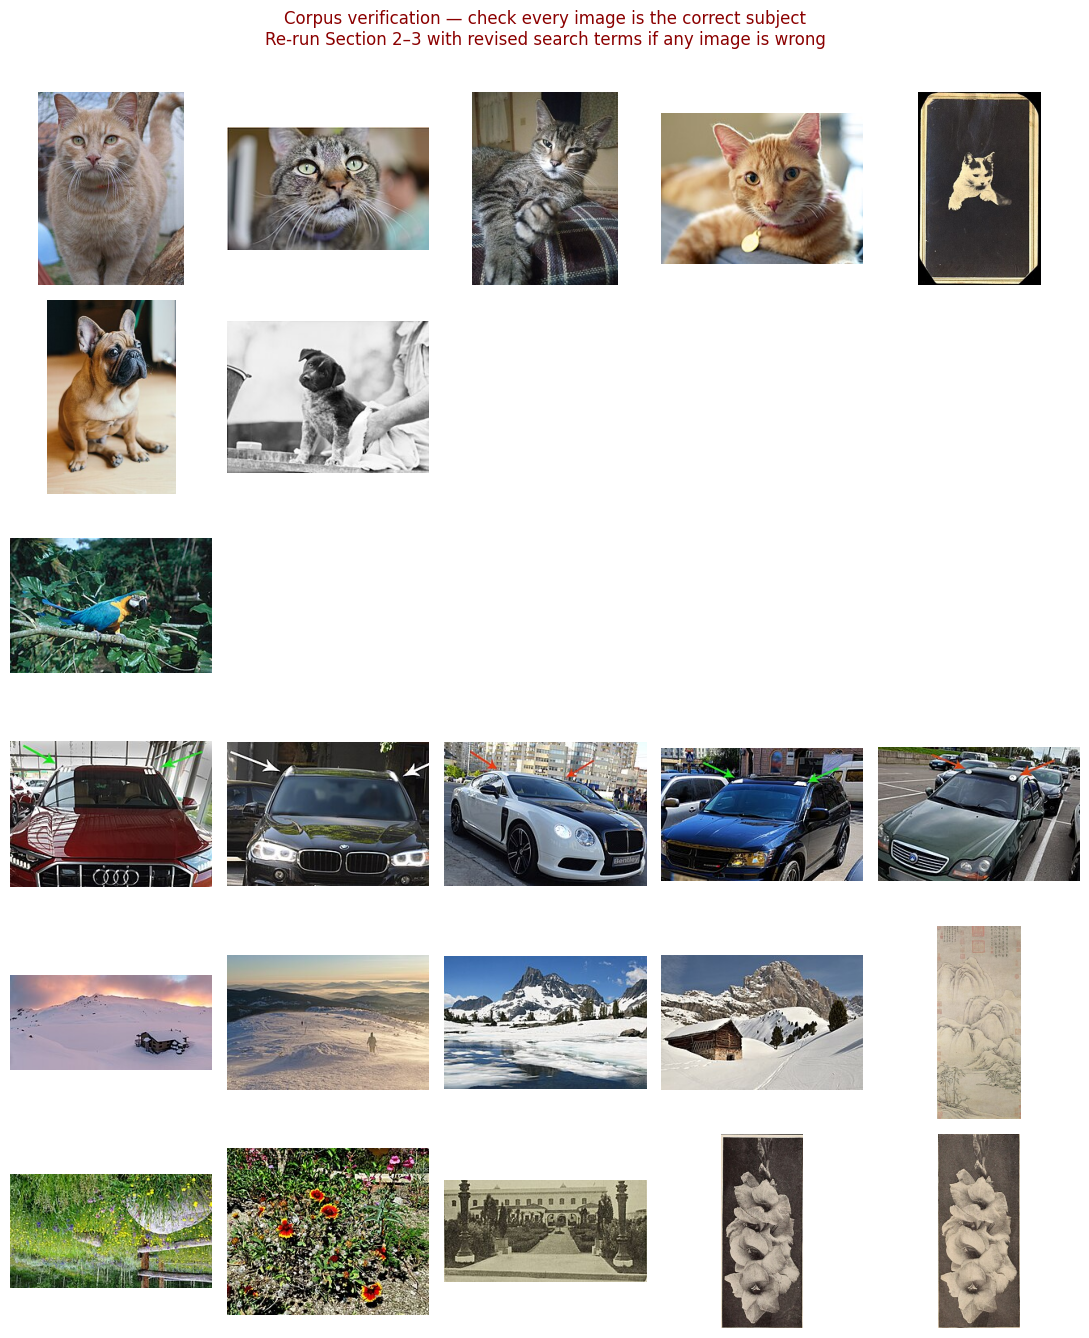


Category      Images downloaded
──────────────────────────────
  cat           5
  dog           2
  bird          1
  car           5
  mountain      5
  flower        5

Total: 23 images — proceed to Section 5 only after visual check ✅


In [4]:
GRID_COLS = IMAGES_PER_CATEGORY
grid_rows = len(CATEGORY_LIST)

fig, axes = plt.subplots(grid_rows, GRID_COLS,
                         figsize=(GRID_COLS * 2.2, grid_rows * 2.2),
                         squeeze=False)

for ax in axes.flat:
    ax.axis("off")

# Group by category so each row is one category
cat_images: dict = {cat: [] for cat in CATEGORY_LIST}
for img, lbl in zip(images_flat, true_labels):
    cat_images[lbl].append(img)

for row_idx, cat in enumerate(CATEGORY_LIST):
    for col_idx, img in enumerate(cat_images[cat][:GRID_COLS]):
        axes[row_idx, col_idx].imshow(img)
        if col_idx == 0:
            axes[row_idx, col_idx].set_ylabel(cat, fontsize=11,
                                               rotation=0, labelpad=50,
                                               va="center", fontweight="bold")

plt.suptitle(
    "Corpus verification — check every image is the correct subject\n"
    "Re-run Section 2–3 with revised search terms if any image is wrong",
    fontsize=12, y=1.01, color="darkred"
)
plt.tight_layout()
plt.show()

print(f"\n{'Category':<12}  Images downloaded")
print("─" * 30)
for cat in CATEGORY_LIST:
    print(f"  {cat:<12}  {len(cat_images[cat])}")
print(f"\nTotal: {N} images — proceed to Section 5 only after visual check ✅")


## 5. Embed with `voyage-multimodal-3`

### Free-tier rate limit
Voyage free tier: **10,000 tokens / minute**.

Images are sent in **batches of 5** with a configurable sleep between each batch.
The cell prints the token count per batch so you can monitor usage.
If you hit a rate-limit error the exponential-backoff retry handles it automatically.

> **Tip**: With 200 px thumbnails each image costs roughly 50–200 tokens.
> At the default settings (5 images / batch, 10 s sleep) the corpus embeds in
> under 2 minutes well within the free tier.


In [5]:
# ── Tune these if you hit rate limits ────────────────────────────────────────
BATCH_SIZE              = 5    # images per multimodal_embed call
SLEEP_BETWEEN_BATCHES   = 10   # seconds between batches (free-tier guard)
MAX_RETRIES             = 6    # exponential-backoff retries per batch
# ─────────────────────────────────────────────────────────────────────────────

def embed_batch_with_retry(inputs: list, input_type: str = "document"):
    """Single multimodal_embed call with exponential backoff on rate-limit errors."""
    for attempt in range(MAX_RETRIES):
        try:
            return vo.multimodal_embed(
                inputs=inputs,
                model="voyage-multimodal-3",
                input_type=input_type,
            )
        except Exception as exc:
            msg = str(exc).lower()
            if any(kw in msg for kw in ("rate", "429", "quota", "limit")):
                wait = (2 ** attempt) + random.uniform(0, 1)
                print(f"    ⏳ Rate limit — retrying in {wait:.1f}s (attempt {attempt + 1}/{MAX_RETRIES})")
                time.sleep(wait)
            else:
                raise   # unexpected error — bubble up immediately
    raise RuntimeError("Max retries exceeded — check Voyage quota at dash.voyageai.com")


def batch_embed(
    pil_images: List[Image.Image],
    input_type: str = "document",
) -> Tuple[np.ndarray, int]:
    """
    Embed a list of PIL images in free-tier-safe batches.

    Returns:
        embeddings  — float32 array of shape (N, embedding_dim)
        total_tokens — cumulative token count across all batches
    """
    all_embeddings: list  = []
    total_tokens:   int   = 0
    n_batches = (len(pil_images) + BATCH_SIZE - 1) // BATCH_SIZE

    for batch_num, start in enumerate(range(0, len(pil_images), BATCH_SIZE), 1):
        batch   = pil_images[start : start + BATCH_SIZE]
        inputs  = [[img] for img in batch]
        result  = embed_batch_with_retry(inputs, input_type=input_type)

        all_embeddings.extend(result.embeddings)
        batch_tokens = result.total_tokens
        total_tokens += batch_tokens

        end = min(start + BATCH_SIZE, len(pil_images))
        print(f"  Batch {batch_num}/{n_batches} "
              f"(images {start + 1}–{end}): "
              f"{batch_tokens:,} tokens  |  running total: {total_tokens:,}")

        # Sleep between batches to respect the free-tier rate limit
        if end < len(pil_images):
            print(f"  ⏸  Sleeping {SLEEP_BETWEEN_BATCHES}s …")
            time.sleep(SLEEP_BETWEEN_BATCHES)

    return np.array(all_embeddings, dtype=np.float32), total_tokens


print(f"Embedding {N} images in batches of {BATCH_SIZE} …\n")
embeddings, total_tokens_used = batch_embed(images_flat)

print(f"\n✅  Done")
print(f"   Embedding matrix : {embeddings.shape}  (images × dimensions)")
print(f"   Total tokens used: {total_tokens_used:,}")


Embedding 23 images in batches of 5 …

  Batch 1/5 (images 1–5): 651 tokens  |  running total: 651
  ⏸  Sleeping 10s …
  Batch 2/5 (images 6–10): 525 tokens  |  running total: 1,176
  ⏸  Sleeping 10s …
  Batch 3/5 (images 11–15): 446 tokens  |  running total: 1,622
  ⏸  Sleeping 10s …
  Batch 4/5 (images 16–20): 618 tokens  |  running total: 2,240
  ⏸  Sleeping 10s …
  Batch 5/5 (images 21–23): 620 tokens  |  running total: 2,860

✅  Done
   Embedding matrix : (23, 1024)  (images × dimensions)
   Total tokens used: 2,860


## 6. PCA

PCA is used for two purposes:

| Purpose | Components | `whiten` |
|---|---|---|
| 2-D visualisation | 2 | False |
| K-Means input + retrieval | 80%-variance cutoff | **True** |

Whitening (`whiten=True`) rescales each PC to unit variance, which spreads
cosine similarities away from the compressed 0.55–0.80 band typical of raw 1024-dim vectors.


Components for 80% variance: 10
Components for 90% variance: 14


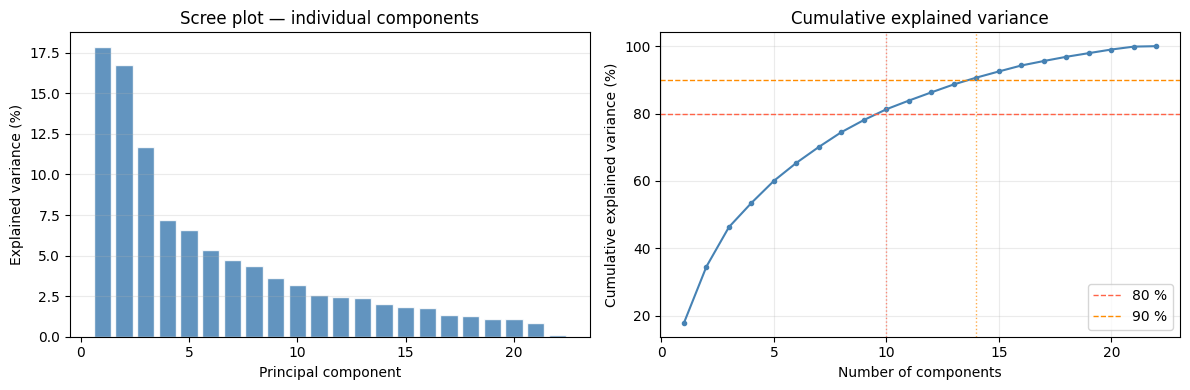

In [6]:
# Maximum meaningful components = N - 1 (can't exceed number of samples minus one)
N_COMPONENTS_MAX = min(N - 1, embeddings.shape[1], 50)

pca_full = PCA(n_components=N_COMPONENTS_MAX, random_state=42)
pca_full.fit(embeddings)

evr     = pca_full.explained_variance_ratio_
cum_evr = np.cumsum(evr)

# How many components cover 80% / 90% of variance?
dims_80 = min(int(np.searchsorted(cum_evr, 0.80)) + 1, N_COMPONENTS_MAX)
dims_90 = min(int(np.searchsorted(cum_evr, 0.90)) + 1, N_COMPONENTS_MAX)

print(f"Components for 80% variance: {dims_80}")
print(f"Components for 90% variance: {dims_90}")

# ── Scree plot ────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(range(1, len(evr) + 1), evr * 100,
        color="steelblue", alpha=0.85, edgecolor="white")
ax1.set_xlabel("Principal component")
ax1.set_ylabel("Explained variance (%)")
ax1.set_title("Scree plot — individual components")
ax1.grid(axis="y", alpha=0.25)

ax2.plot(range(1, len(cum_evr) + 1), cum_evr * 100,
         marker=".", color="steelblue", linewidth=1.5)
ax2.axhline(80, color="tomato",     linestyle="--", linewidth=1, label="80 %")
ax2.axhline(90, color="darkorange", linestyle="--", linewidth=1, label="90 %")
ax2.axvline(dims_80, color="tomato",     linestyle=":", linewidth=1, alpha=0.7)
ax2.axvline(dims_90, color="darkorange", linestyle=":", linewidth=1, alpha=0.7)
ax2.set_xlabel("Number of components")
ax2.set_ylabel("Cumulative explained variance (%)")
ax2.set_title("Cumulative explained variance")
ax2.legend()
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()


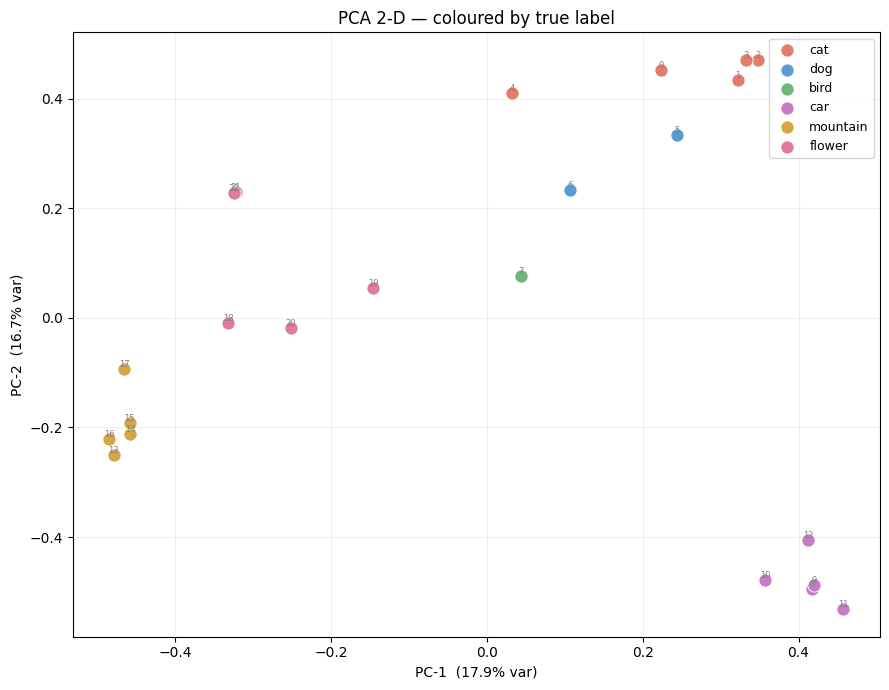

In [7]:
# ── 2-D PCA scatter coloured by true label ────────────────────────────────────
pca_2d = PCA(n_components=2, random_state=42)
coords = pca_2d.fit_transform(embeddings)   # (N, 2)

PALETTE = {
    "cat":      "#E27C6D",
    "dog":      "#5B9BD5",
    "bird":     "#70B679",
    "car":      "#C77DC5",
    "mountain": "#D4A646",
    "flower":   "#E07B9E",
}

fig, ax = plt.subplots(figsize=(9, 7))
for cat in CATEGORY_LIST:
    mask = [i for i, l in enumerate(true_labels) if l == cat]
    ax.scatter(coords[mask, 0], coords[mask, 1],
               label=cat, color=PALETTE.get(cat, "gray"),
               s=90, edgecolors="white", linewidths=0.6, zorder=3)
    for idx in mask:
        ax.annotate(str(idx),
                    (coords[idx, 0], coords[idx, 1]),
                    fontsize=6, ha="center", va="bottom", color="gray")

ax.set_xlabel(f"PC-1  ({pca_2d.explained_variance_ratio_[0] * 100:.1f}% var)")
ax.set_ylabel(f"PC-2  ({pca_2d.explained_variance_ratio_[1] * 100:.1f}% var)")
ax.set_title("PCA 2-D — coloured by true label")
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 7. Whitened PCA — shared space for K-Means and retrieval

A **single** whitened PCA is fitted once and reused for both K-Means clustering
and for projecting query embeddings at retrieval time, avoiding any inconsistency
between two separate embedding spaces.


In [8]:
# Use dims_80 from the PCA cell; fall back to 10 if that cell was skipped
if "dims_80" not in dir():
    dims_80 = 10
N_WHITE = dims_80

pca_white = PCA(n_components=N_WHITE, whiten=True, random_state=42)
corpus_w  = pca_white.fit_transform(embeddings)   # (N, N_WHITE)
corpus_w  = normalize(corpus_w)                    # L2-normalise after whitening

# Quick sanity check: raw vs whitened mean pairwise cosine
def mean_pairwise_cosine(mat: np.ndarray) -> float:
    normed = normalize(mat)
    sims = normed @ normed.T
    mask = ~np.eye(len(mat), dtype=bool)
    return float(sims[mask].mean())

raw_mean = mean_pairwise_cosine(embeddings)
wht_mean = mean_pairwise_cosine(corpus_w)

print(f"Whitened corpus shape  : {corpus_w.shape}  (≥80% variance retained)")
print(f"Mean pairwise cosine   : {raw_mean:.3f} (raw 1024-dim)  →  {wht_mean:.3f} (whitened)")
print("Lower mean after whitening = more discriminative score range")


Whitened corpus shape  : (23, 10)  (≥80% variance retained)
Mean pairwise cosine   : 0.282 (raw 1024-dim)  →  -0.041 (whitened)
Lower mean after whitening = more discriminative score range


## 8. K-Means clustering

K-Means runs on the **whitened PCA vectors** (not raw 1024-dim embeddings).
The elbow method helps identify the right number of clusters.


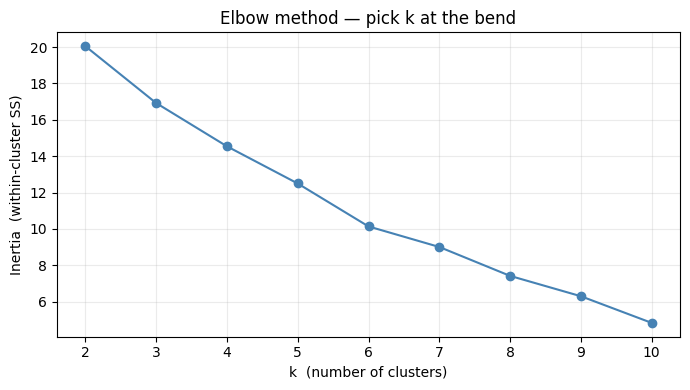

In [9]:
# ── Elbow method ─────────────────────────────────────────────────────────────
K_RANGE  = range(2, min(N // 2, 13))
inertias = []

for k in K_RANGE:
    km_tmp = KMeans(n_clusters=k, n_init=15, random_state=42)
    km_tmp.fit(corpus_w)
    inertias.append(km_tmp.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(K_RANGE), inertias, marker="o", color="steelblue", linewidth=1.5)
ax.set_xlabel("k  (number of clusters)")
ax.set_ylabel("Inertia  (within-cluster SS)")
ax.set_title("Elbow method — pick k at the bend")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [10]:
# ── Fit final K-Means ─────────────────────────────────────────────────────────
# Default = number of true categories; adjust if the elbow suggests otherwise.
K_OPTIMAL = len(CATEGORY_LIST)

km             = KMeans(n_clusters=K_OPTIMAL, n_init=30, random_state=42)
km.fit(corpus_w)
cluster_labels = km.labels_                          # (N,) — int cluster id
centroids      = normalize(km.cluster_centers_)     # (k, N_WHITE)

print(f"K-Means fitted  k={K_OPTIMAL}\n")
print(f"{'Cluster':<10}  {'n':>3}  Composition")
print("─" * 50)
for c in range(K_OPTIMAL):
    members = [true_labels[i] for i in range(N) if cluster_labels[i] == c]
    counts  = dict(sorted(Counter(members).items()))
    print(f"  Cluster {c}   {len(members):>3}  {counts}")


K-Means fitted  k=6

Cluster       n  Composition
──────────────────────────────────────────────────
  Cluster 0     4  {'car': 4}
  Cluster 1     4  {'car': 1, 'flower': 1, 'mountain': 2}
  Cluster 2     5  {'cat': 5}
  Cluster 3     4  {'flower': 1, 'mountain': 3}
  Cluster 4     3  {'flower': 3}
  Cluster 5     3  {'bird': 1, 'dog': 2}


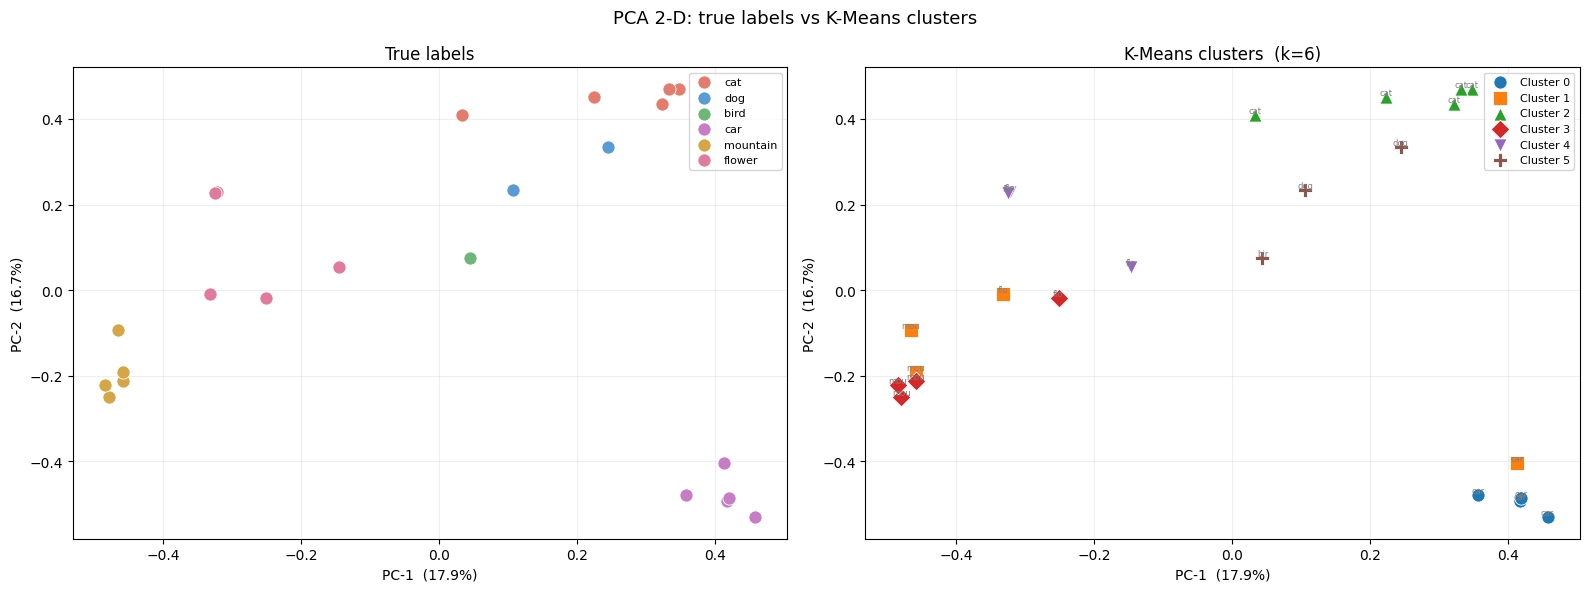

In [11]:
# ── Side-by-side 2-D scatter: true labels vs cluster assignments ──────────────
CLUSTER_COLORS  = plt.cm.tab10.colors
CLUSTER_MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*", "h", "p"]

fig, (ax_true, ax_km) = plt.subplots(1, 2, figsize=(16, 6))

for cat in CATEGORY_LIST:
    mask = [i for i, l in enumerate(true_labels) if l == cat]
    ax_true.scatter(coords[mask, 0], coords[mask, 1],
                    label=cat, color=PALETTE.get(cat, "gray"),
                    s=90, edgecolors="white", linewidths=0.6, zorder=3)
ax_true.set_title("True labels")
ax_true.set_xlabel(f"PC-1  ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
ax_true.set_ylabel(f"PC-2  ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
ax_true.legend(fontsize=8)
ax_true.grid(alpha=0.2)

for c in range(K_OPTIMAL):
    mask = [i for i in range(N) if cluster_labels[i] == c]
    ax_km.scatter(coords[mask, 0], coords[mask, 1],
                  label=f"Cluster {c}",
                  color=CLUSTER_COLORS[c % 10],
                  marker=CLUSTER_MARKERS[c % len(CLUSTER_MARKERS)],
                  s=90, edgecolors="white", linewidths=0.6, zorder=3)
    for idx in mask:
        ax_km.annotate(true_labels[idx][:3],
                       (coords[idx, 0], coords[idx, 1]),
                       fontsize=6, ha="center", va="bottom", color="gray")

ax_km.set_title(f"K-Means clusters  (k={K_OPTIMAL})")
ax_km.set_xlabel(f"PC-1  ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
ax_km.set_ylabel(f"PC-2  ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
ax_km.legend(fontsize=8)
ax_km.grid(alpha=0.2)

plt.suptitle("PCA 2-D: true labels vs K-Means clusters", fontsize=13)
plt.tight_layout()
plt.show()


## 9. Cluster purity analysis

The confusion matrix shows how well `voyage-multimodal-3` separates semantic categories.
**Purity** = fraction of images that belong to the majority category in their cluster
(1.0 = perfect separation).


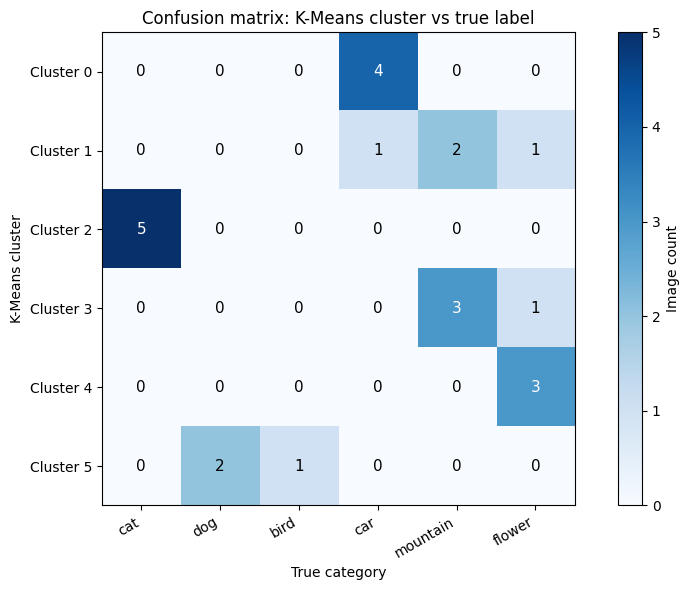

Cluster purity: 0.826   (1.0 = every cluster is a single category)


In [12]:
# ── Confusion matrix heatmap ─────────────────────────────────────────────────
cm = np.zeros((K_OPTIMAL, len(CATEGORY_LIST)), dtype=int)
for i in range(N):
    cm[cluster_labels[i], true_label_idx[i]] += 1

fig, ax = plt.subplots(figsize=(9, max(4, K_OPTIMAL)))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CATEGORY_LIST)))
ax.set_yticks(range(K_OPTIMAL))
ax.set_xticklabels(CATEGORY_LIST, rotation=30, ha="right", fontsize=10)
ax.set_yticklabels([f"Cluster {c}" for c in range(K_OPTIMAL)], fontsize=10)
ax.set_xlabel("True category")
ax.set_ylabel("K-Means cluster")
ax.set_title("Confusion matrix: K-Means cluster vs true label")

for r in range(K_OPTIMAL):
    for col in range(len(CATEGORY_LIST)):
        color = "white" if cm[r, col] > cm.max() / 2 else "black"
        ax.text(col, r, str(cm[r, col]),
                ha="center", va="center", fontsize=11, color=color)

plt.colorbar(im, ax=ax, label="Image count")
plt.tight_layout()
plt.show()

purity = sum(cm[r].max() for r in range(K_OPTIMAL)) / N
print(f"Cluster purity: {purity:.3f}   (1.0 = every cluster is a single category)")


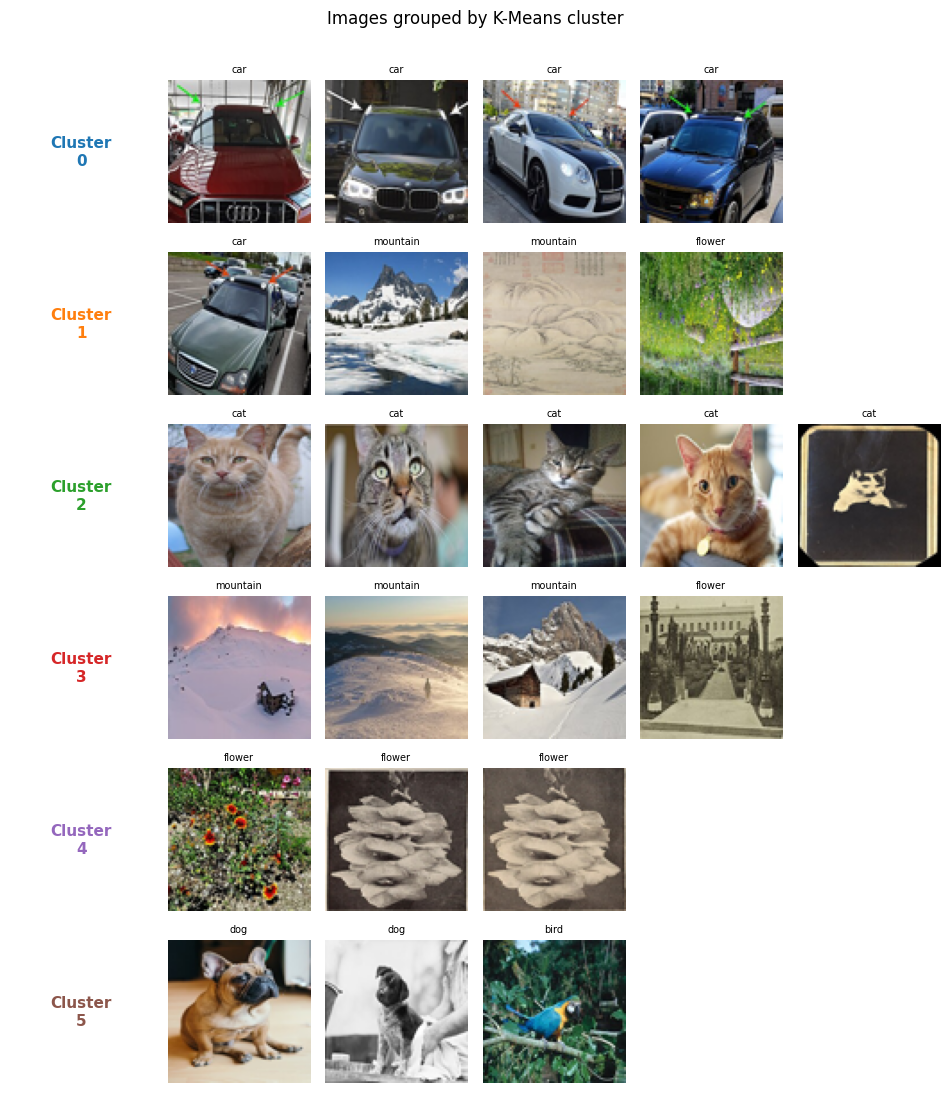

In [13]:
# ── Image thumbnails grouped by cluster ───────────────────────────────────────
THUMB = (80, 80)
N_COLS = IMAGES_PER_CATEGORY + 1   # label column + up-to-5 image columns

fig, axes = plt.subplots(K_OPTIMAL, N_COLS,
                         figsize=(N_COLS * 1.6, K_OPTIMAL * 1.8),
                         squeeze=False)    # always a 2-D array

for ax in axes.flat:
    ax.axis("off")

for c in range(K_OPTIMAL):
    members = [i for i in range(N) if cluster_labels[i] == c]

    # Column 0 — cluster label
    axes[c, 0].text(0.5, 0.5, f"Cluster\n{c}",
                    ha="center", va="center",
                    fontsize=11, fontweight="bold",
                    color=CLUSTER_COLORS[c % 10],
                    transform=axes[c, 0].transAxes)

    # Columns 1..IMAGES_PER_CATEGORY — thumbnails
    for col_offset, img_idx in enumerate(members[:IMAGES_PER_CATEGORY], start=1):
        axes[c, col_offset].imshow(images_flat[img_idx].resize(THUMB))
        axes[c, col_offset].set_title(true_labels[img_idx], fontsize=7)

plt.suptitle("Images grouped by K-Means cluster", y=1.01, fontsize=12)
plt.tight_layout()
plt.show()


## 10. Cluster-aware text → image retrieval

Pipeline for a text query:
1. Embed the query with `input_type="query"` (uses free-tier rate-limit guard)
2. Project into the **same** whitened PCA space
3. Find the nearest cluster centroid (fast dot-product over *k* vectors)
4. Rank images **within that cluster only** by cosine similarity

This is compared against brute-force cosine over all 30 images.


In [14]:
def cosine(a: np.ndarray, b: np.ndarray) -> float:
    """Safe cosine similarity for two 1-D float arrays."""
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / denom) if denom > 1e-10 else 0.0


def retrieve_cluster_aware(
    query_raw: np.ndarray,
    top_k: int = 3,
) -> Tuple[int, List[Tuple[str, float, int]]]:
    """
    Cluster-aware retrieval in the whitened PCA space.
    Returns (best_cluster_id, [(label, score, image_index), …]).
    """
    q_w         = normalize(pca_white.transform(query_raw.reshape(1, -1)))[0]
    best_cluster = int(np.argmax([cosine(q_w, c) for c in centroids]))
    members      = [i for i in range(N) if cluster_labels[i] == best_cluster]
    ranked       = sorted(members, key=lambda i: cosine(q_w, corpus_w[i]), reverse=True)
    results      = [(true_labels[i], cosine(q_w, corpus_w[i]), i) for i in ranked[:top_k]]
    return best_cluster, results


def retrieve_brute_force(
    query_raw: np.ndarray,
    top_k: int = 3,
) -> List[Tuple[str, float, int]]:
    """Brute-force cosine in raw 1024-dim space (baseline)."""
    ranked = sorted(range(N),
                    key=lambda i: cosine(query_raw, embeddings[i]),
                    reverse=True)
    return [(true_labels[i], cosine(query_raw, embeddings[i]), i) for i in ranked[:top_k]]


In [15]:
TEXT_QUERIES = [
    "a fluffy domestic cat",
    "a labrador retriever sitting outdoors",
    "a colourful tropical bird perched on a branch",
    "a red sports car on the road",
    "a snow-capped mountain peak",
    "a bright yellow sunflower in bloom",
]

# Embed all queries in one call (6 short texts ≈ <200 tokens — well within free tier)
print("Embedding text queries …")
q_result   = embed_batch_with_retry([[q] for q in TEXT_QUERIES], input_type="query")
query_embs = np.array(q_result.embeddings, dtype=np.float32)
print(f"Tokens used for queries: {q_result.total_tokens}\n")

# ── Comparison table ──────────────────────────────────────────────────────────
hdr = (f"{'Query':<45}  {'Cluster':>8}  "
       f"{'Cluster-aware top-1':>22}  {'Brute-force top-1':>20}  Match")
print(hdr)
print("─" * len(hdr))

for query, q_emb in zip(TEXT_QUERIES, query_embs):
    best_cluster, ca = retrieve_cluster_aware(q_emb)
    bf               = retrieve_brute_force(q_emb)

    ca_label, ca_score, _ = ca[0]
    bf_label, bf_score, _ = bf[0]
    match = "✓" if ca_label == bf_label else "✗"

    print(f"{query[:43]:<45}  C{best_cluster:>7}  "
          f"{ca_label:>20} {ca_score:.3f}  "
          f"{bf_label:>16} {bf_score:.3f}  {match}")


Embedding text queries …
Tokens used for queries: 34

Query                                           Cluster     Cluster-aware top-1     Brute-force top-1  Match
────────────────────────────────────────────────────────────────────────────────────────────────────────────
a fluffy domestic cat                          C      2                   cat 0.730               cat 0.476  ✓
a labrador retriever sitting outdoors          C      5                   dog 0.873               dog 0.467  ✓
a colourful tropical bird perched on a bran    C      5                  bird 0.937              bird 0.560  ✓
a red sports car on the road                   C      0                   car 0.797               car 0.442  ✓
a snow-capped mountain peak                    C      3              mountain 0.598          mountain 0.488  ✓
a bright yellow sunflower in bloom             C      4                flower 0.704            flower 0.381  ✓


## 11. Score distribution: raw cosine vs whitened cosine

A higher standard deviation after whitening means the scores are more
spread out — the model's ranking signal is more discriminative.


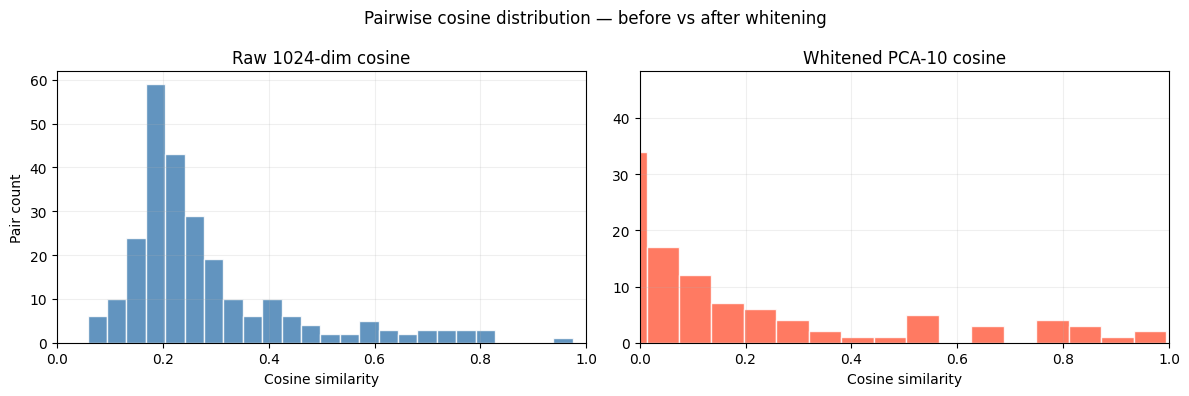

Raw cosine      — mean: 0.282  std: 0.1640
Whitened cosine — mean: -0.041  std: 0.2702

A lower mean and higher std after whitening = more discriminative scores ✅


In [16]:
raw_scores, whitened_scores = [], []
for i in range(N):
    for j in range(i + 1, N):
        raw_scores.append(cosine(embeddings[i], embeddings[j]))
        whitened_scores.append(cosine(corpus_w[i], corpus_w[j]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(raw_scores,      bins=25, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].set_title("Raw 1024-dim cosine")
axes[0].set_xlabel("Cosine similarity")
axes[0].set_ylabel("Pair count")
axes[0].set_xlim(0, 1)
axes[0].grid(alpha=0.2)

axes[1].hist(whitened_scores, bins=25, color="tomato",    edgecolor="white", alpha=0.85)
axes[1].set_title(f"Whitened PCA-{N_WHITE} cosine")
axes[1].set_xlabel("Cosine similarity")
axes[1].set_xlim(0, 1)
axes[1].grid(alpha=0.2)

plt.suptitle("Pairwise cosine distribution — before vs after whitening", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Raw cosine      — mean: {np.mean(raw_scores):.3f}  std: {np.std(raw_scores):.4f}")
print(f"Whitened cosine — mean: {np.mean(whitened_scores):.3f}  std: {np.std(whitened_scores):.4f}")
print("\nA lower mean and higher std after whitening = more discriminative scores ✅")


## 12. What next?

| Technique | When to reach for it |
|---|---|
| **Grow the corpus** | PCA and K-Means improve with 100–500 images |
| **Auto-captions** | Use Claude / GPT-4o to generate per-image descriptions; embed as `[image, caption]` |
| **HDBSCAN** | When the number of clusters is unknown or clusters are non-spherical |
| **Cross-encoder re-ranking** | VLM scores the (query, top-k image) pairs for a finer ranking |
| **Query expansion** | Paraphrase the query 3–5 times; average the score vectors before ranking |
| **Tune `K_OPTIMAL`** | If purity < 0.8, try `k > len(CATEGORY_LIST)` — some semantic groups may need sub-clusters |
